In [44]:
import numpy as np
import random
from sklearn.linear_model import LinearRegression
from scipy import stats
import json

In [45]:
np.random.seed(2026)

Генрация выборки n = 50
$$
(\xi_1, \xi_2, \xi_3, \xi_4, \xi_5, \eta)
$$
$$
\xi_k \sim R(-1,1)
$$

$$
\eta \sim N(2 + 3x_1 - 2x_2 + x_3 + x_4 - x_5, 1.5^2)
$$

$$
x_k - \text{значение, которое принимает } \xi_k
$$


In [46]:
import numpy as np

n = 50

ksi = np.random.uniform(-1, 1, (n, 5))

mean = 2 + 3*ksi[:,0] - 2*ksi[:,1] + ksi[:,2] + ksi[:,3] - ksi[:,4]

eta = np.random.normal(mean, 1.5)

vec = np.concatenate([ksi, eta.reshape(-1, 1)], axis=1)

In [47]:
with open('data.json', 'w', encoding='utf-8') as f:
    json.dump(vec.tolist(), f, indent=2)

In [48]:
print(vec.shape)
print(vec[:10])

(50, 6)
[[-0.56130873 -0.17397653  0.95327096 -0.82220196 -0.04142028 -0.50695418]
 [ 0.97510099 -0.60371782  0.82343036  0.11650023  0.56645894  5.57474782]
 [-0.39504682 -0.20539801 -0.40806537  0.78817692 -0.90364979  4.15590303]
 [-0.10986471  0.12378778 -0.27257074  0.38898616  0.84673616  1.94088806]
 [-0.93881386 -0.75718912 -0.53618726  0.2857939  -0.5281328   0.29307876]
 [ 0.93373154 -0.70166573 -0.90620712 -0.05909771  0.36515497  6.2303456 ]
 [ 0.75876632  0.36584074  0.04057325 -0.06598888 -0.4851988   5.96377173]
 [ 0.01605656  0.14893959 -0.01971623 -0.58564    -0.09823288  0.81056611]
 [ 0.87985772 -0.37649255 -0.95399486 -0.50180832 -0.57803312  6.3141511 ]
 [-0.59474656  0.34199468  0.48449089  0.7091047  -0.83130243  0.97336732]]


$$
\xi_1 предск = bo + b2*\xi2 + b3*\xi3 + b4*\xi4 + b5*\xi5
$$

a) Мультиколлинеарность

In [49]:

n = 50

bad_variables = []
all_results = []

for i in range(5):
    remaining_indices = [j for j in range(5) if j != i and j not in bad_variables]
    
    if len(remaining_indices) == 0:
        print(f"Нет доступных факторов для ξ{i+1} (все остальные уже исключены)")
        all_results.append({
            'variable': f'ξ{i+1}',
            'R²': None,
            'status': 'не проверена (нет факторов)',
            'excluded': False
        })
        continue
    
    y = vec[:, i]
    
    X_factors = vec[:, remaining_indices]
    
    factor_names = [f'ξ{j+1}' for j in remaining_indices]
    
    
    model = LinearRegression()
    model.fit(X_factors, y)
    y_pred = model.predict(X_factors)
    
    RSS = np.sum((y - y_pred)**2)
    TSS = np.sum((y - np.mean(y))**2)
    R2 = 1 - RSS/TSS
    
    print(f"  RSS = {RSS:.4f}")
    print(f"  TSS = {TSS:.4f}")
    print(f"  R² = {R2:.4f}")
    
    if R2 > 0.7:
        bad_variables.append(i)
        excluded = True
    else:
        status = "ОСТАВЛЕНА"
        excluded = False
    
    all_results.append({
        'variable': f'ξ{i+1}',
        'R²': R2,
        'status': status,
        'excluded': excluded,
        'factors': factor_names
    })


for res in all_results:
    if res['R²'] is not None:
        print(f"  {res['variable']}: R² = {res['R²']:.4f} → {res['status']}")
    else:
        print(f"  {res['variable']}: {res['status']}")

print(f"\nИсключенные переменные: {[f'ξ{b+1}' for b in bad_variables]}")
print(f"Оставленные переменные: {[f'ξ{i+1}' for i in range(5) if i not in bad_variables]}")

if len(bad_variables) == 0:
    print("\nМультиколлинеарности нет. Все переменные независимы.")
else:
    print(f"\nРекомендуется удалить {[f'ξ{b+1}' for b in bad_variables]}")

results_to_save = {
    'bad_variables': [f'ξ{b+1}' for b in bad_variables],
    'good_variables': [f'ξ{i+1}' for i in range(5) if i not in bad_variables],
    'details': all_results,
    'n_samples': n,
    'threshold': 0.7
}



  RSS = 15.2112
  TSS = 16.6166
  R² = 0.0846
  RSS = 15.2170
  TSS = 16.5655
  R² = 0.0814
  RSS = 17.0167
  TSS = 17.6657
  R² = 0.0367
  RSS = 17.7736
  TSS = 19.0721
  R² = 0.0681
  RSS = 16.5295
  TSS = 18.6541
  R² = 0.1139
  ξ1: R² = 0.0846 → ОСТАВЛЕНА
  ξ2: R² = 0.0814 → ОСТАВЛЕНА
  ξ3: R² = 0.0367 → ОСТАВЛЕНА
  ξ4: R² = 0.0681 → ОСТАВЛЕНА
  ξ5: R² = 0.1139 → ОСТАВЛЕНА

Исключенные переменные: []
Оставленные переменные: ['ξ1', 'ξ2', 'ξ3', 'ξ4', 'ξ5']

Мультиколлинеарности нет. Все переменные независимы.


In [50]:
with open('1a.json', 'w', encoding='utf-8') as f:
    json.dump(results_to_save, f, indent=2, ensure_ascii=False)

b)
$\eta = \beta_0 + \sum_{k=1}^{5} \beta_k \xi_k$ 
Определиь уравнение регрессии и проверить значимость коэффициентов

$$\mathbf{F} = \mathbf{X}^T\mathbf{X}$$
$$\mathbf{e} = \mathbf{Y} - \mathbf{X}\hat{\boldsymbol{\beta}}$$

$$t_i = \frac{\hat{\beta}_i - \beta_i}{\sqrt{RSS \cdot (\mathbf{X}^T\mathbf{X})^{-1}_{ii}}}\sqrt{n-p} \sim t(n-p)$$
$$\text{H0: }  \beta_i = 0$$

In [51]:
Y = vec[:, 5]
X = vec[:, 0:5]

model = LinearRegression(fit_intercept=True)
model.fit(X, Y)

beta_hat = np.append(model.intercept_, model.coef_)

Y_pred = model.predict(X)

residuals = Y - Y_pred
RSS = np.sum(residuals**2)

n = len(Y)
p = X.shape[1] + 1  # 6 параметров

# Для стандартных ошибок нужна матрица X с единицами
X_with_intercept = np.column_stack([np.ones(n), X])

sigma2_hat = RSS / (n - p)

# Обратная матрица (X'X)^(-1)
X_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)

# Стандартные ошибки
SE = np.sqrt(sigma2_hat * np.diag(X_inv))

t_stats = beta_hat / SE

df = n - p

p_values = 2 * stats.t.sf(np.abs(t_stats), df=df)

print(f"Степени свободы: df = {df}")
print(f"σ̂² = {sigma2_hat:.4f}")

print(f"\n{'Коэфф.':<8} {'β̂':<10} {'SE':<10} {'t-стат':<10} {'p-value':<10} {'Значим':<8}")
print("-"*70)

for i, (b, se, t, p) in enumerate(zip(beta_hat, SE, t_stats, p_values)):
    significant = "ДА" if p < 0.05 else "нет"
    print(f"β{i:<7} {b:<10.4f} {se:<10.4f} {t:<10.4f} {p:<10.4f} {significant:<8}")

alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df=df)
print(f"\nКритическое значение t({df}) = ±{t_critical:.3f}")

Степени свободы: df = 44
σ̂² = 2.4748

Коэфф.   β̂         SE         t-стат     p-value    Значим  
----------------------------------------------------------------------
β0       1.9699     0.2259     8.7205     0.0000     ДА      
β1       2.9485     0.4034     7.3098     0.0000     ДА      
β2       -2.1777    0.4033     -5.4000    0.0000     ДА      
β3       0.5454     0.3814     1.4301     0.1597     нет     
β4       0.3370     0.3732     0.9032     0.3713     нет     
β5       -1.0800    0.3869     -2.7911    0.0077     ДА      

Критическое значение t(44) = ±2.015


In [52]:
results_compact = {
    "model": "η = β₀ + Σ βₖξₖ",
    "n": n,
    "df": df,
    "sigma2": round(sigma2_hat, 4),
    "R2": round(model.score(X, Y), 4),
    "coefficients": {
        f"β{i}": {
            "estimate": round(beta_hat[i], 4),
            "se": round(SE[i], 4),
            "t_stat": round(t_stats[i], 4),
            "p_value": round(p_values[i], 4),
            "significant": round(p_values[i], 4)
        }
        for i in range(len(beta_hat))
    }
}

with open('1b.json', 'w', encoding='utf-8') as f:
    json.dump(results_compact, f, indent=2, ensure_ascii=False)

C) Значимость коэффициента детерминации R^2

In [53]:
from sklearn.linear_model import LinearRegression

Y = vec[:, 5]
X = vec[:, 0:5]

model = LinearRegression(fit_intercept=True)
model.fit(X, Y)
y_pred = model.predict(X)

RSS = np.sum((Y - y_pred)**2)
TSS = np.sum((Y - np.mean(Y))**2)
R2 = 1 - RSS/TSS

print(f"RSS = {RSS:.4f}")
print(f"TSS = {TSS:.4f}")
print(f"R² = {R2:.4f}")

RSS = 108.8929
TSS = 302.8171
R² = 0.6404


In [54]:
result = {"R^2": R2}

with open('1c.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

d) xk = 0 . 95% доверительный интервал
$$
\eta = \beta_0
$$

In [55]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats
import matplotlib.pyplot as plt
import json

# ξ = 0

Y = vec[:, 5]
X = vec[:, 0:5]
n = len(Y)

# 1. Исходная модель
model = LinearRegression()
model.fit(X, Y)

beta_hat = np.append(model.intercept_, model.coef_)
y_pred_original = model.predict(X)
residuals = Y - y_pred_original
sigma_hat = np.std(residuals, ddof=1)

x_new = np.zeros((1, 5))  # [0, 0, 0, 0, 0]

# Прогноз в этой точке — это просто β₀
y0_point = model.intercept_

print(f"Модель: η = {model.intercept_:.4f}", end="")
for i, coef in enumerate(model.coef_):
    print(f" + ({coef:.4f})·ξ{i+1}", end="")
print()
print(f"\nПри ξ₁=ξ₂=ξ₃=ξ₄=ξ₅=0:")
print(f"η(x=0) = β₀ = {y0_point:.4f}")

# 2. ПАРАМЕТРИЧЕСКИЙ БУТСТРАП
B = 10000
np.random.seed(123)

beta0_boot = np.zeros(B)

for b in range(B):
    # Генерируем новые Y* из модели: Y* = Xβ̂ + ε*, ε* ~ N(0, σ̂²)
    Y_star = y_pred_original + np.random.normal(0, sigma_hat, n)
    
    # Оцениваем модель на бутстрап-данных
    model_boot = LinearRegression()
    model_boot.fit(X, Y_star)
    
    # Сохраняем β₀ (это прогноз в x=0)
    beta0_boot[b] = model_boot.intercept_

# 3. Доверительный интервал
alpha = 0.05
CI_lower = np.percentile(beta0_boot, 100 * alpha/2)
CI_upper = np.percentile(beta0_boot, 100 * (1 - alpha/2))

print(f"\nПАРАМЕТРИЧЕСКИЙ БУТСТРАП (B={B})")
print(f"Точечная оценка: η̂(0) = {y0_point:.4f}")
print(f"95% доверительный интервал: [{CI_lower:.4f}, {CI_upper:.4f}]")
print(f"Ширина интервала: {CI_upper - CI_lower:.4f}")

print(f"Бутстрап 95% CI:       [{CI_lower:.4f}, {CI_upper:.4f}]")

Модель: η = 1.9699 + (2.9485)·ξ1 + (-2.1777)·ξ2 + (0.5454)·ξ3 + (0.3370)·ξ4 + (-1.0800)·ξ5

При ξ₁=ξ₂=ξ₃=ξ₄=ξ₅=0:
η(x=0) = β₀ = 1.9699

ПАРАМЕТРИЧЕСКИЙ БУТСТРАП (B=10000)
Точечная оценка: η̂(0) = 1.9699
95% доверительный интервал: [1.5507, 2.3969]
Ширина интервала: 0.8462
Бутстрап 95% CI:       [1.5507, 2.3969]


In [56]:
import json
import numpy as np

bootstrap_results = {
    "parametric_bootstrap": {
        "method": "Параметрический бутстрап",
        "B": int(B),
        "point_prediction": {
            "x": [0, 0, 0, 0, 0],
            "eta_hat": round(float(y0_point), 4)
        },
        "confidence_interval_95": {
            "lower": round(float(CI_lower), 4),
            "upper": round(float(CI_upper), 4),
            "width": round(float(CI_upper - CI_lower), 4)
        },
        "alpha": 0.05,
        "interpretation": f"С вероятностью 95% истинное значение η при ξ=0 лежит в интервале [{CI_lower:.4f}, {CI_upper:.4f}]"
    }
}

with open('1d.json', 'w', encoding='utf-8') as f:
    json.dump(bootstrap_results, f, indent=2, ensure_ascii=False)

## Тест инверсий для проверки независимости ошибок измерения

### 1. Остатки модели
$$e_i = y_i - \hat{y}_i, \quad i = 1, 2, \ldots, n$$

### 2. Разности остатков
$$d_i = e_{i+1} - e_i, \quad i = 1, 2, \ldots, n-1$$

### 3. Знаки разностей
$$s_i = \text{sign}(d_i) = \begin{cases} +1, & d_i > 0 \\ -1, & d_i < 0 \\ 0, & d_i = 0 \end{cases}$$

### 4. Количество инверсий
$$K = \sum_{i=1}^{n-2} \mathbb{I}(s_i \neq s_{i+1}, s_i \neq 0, s_{i+1} \neq 0)$$

### 5. Гипотезы
$$H_0: \text{остатки независимы (случайны)}$$
$$H_1: \text{остатки зависимы (есть автокорреляция)}$$

### 6. Распределение при $H_0$
$$K \sim N(\mu_K, \sigma_K^2)$$

$$\mu_K = \frac{2n - 4}{3}$$

$$\sigma_K^2 = \frac{16n - 29}{90}$$

### 7. Стандартизованная статистика
$$Z = \frac{K - \frac{2n-4}{3}}{\sqrt{\frac{16n-29}{90}}} \sim N(0,1)$$

### 8. p-value
$$p = 2 \cdot (1 - \Phi(|z|)) = \frac{2}{\sqrt{2\pi}} \int_{|z|}^{\infty} e^{-\frac{t^2}{2}} dt$$

### 9. Правило принятия решения
- Если $p < \alpha \Rightarrow$ отвергаем $H_0$ (остатки зависимы)
- Если $p \geq \alpha \Rightarrow$ нет оснований отвергнуть $H_0$ (остатки независимы)

### 10. Критическое значение для $\alpha = 0.05$
$$|z_{крит}| = 1.96$$

### 11. Доверительный интервал для $K$
$$K \in \left[ \frac{2n-4}{3} - 1.96 \cdot \sqrt{\frac{16n-29}{90}}, \; \frac{2n-4}{3} + 1.96 \cdot \sqrt{\frac{16n-29}{90}} \right]$$

### 12. Пример для $n = 50$
$$\mu_K = \frac{2 \cdot 50 - 4}{3} = 32$$

$$\sigma_K^2 = \frac{16 \cdot 50 - 29}{90} = \frac{771}{90} \approx 8.567$$

$$\sigma_K \approx 2.927$$

In [57]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

Y = vec[:, 5]
X = vec[:, 0:5]

model = LinearRegression()
model.fit(X, Y)
y_pred = model.predict(X)

e = Y - y_pred

d = np.diff(e)  # e_{i+1} - e_i

signs = np.sign(d)

# инверсии (смены знака)
K = 0
for i in range(len(signs) - 1):
    if signs[i] != 0 and signs[i+1] != 0 and signs[i] != signs[i+1]:
        K += 1

n = len(e)

E_K = (2*n - 4) / 3
Var_K = (16*n - 29) / 90
Z = (K - E_K) / np.sqrt(Var_K)

p_value = 2 * (1 - stats.norm.cdf(abs(Z)))


print(f"Количество инверсий K = {K}")
print(f"E[K] = {E_K:.2f}")
print(f"Var[K] = {Var_K:.2f}")
print(f"Z-статистика = {Z:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nH₀ ОТВЕРГАЕТСЯ: остатки ЗАВИСИМЫ (p < {alpha})")
else:
    print(f"\nH₀ НЕ ОТВЕРГАЕТСЯ: остатки независимы (p ≥ {alpha})")

Количество инверсий K = 33
E[K] = 32.00
Var[K] = 8.57
Z-статистика = 0.3417
p-value = 0.7326

H₀ НЕ ОТВЕРГАЕТСЯ: остатки независимы (p ≥ 0.05)


РЕЗУЛЬТАТЫ РЕАЛЬНОЙ МОДЕЛИ
n = 50
β₀ = 1.9699
β = [ 2.94845663 -2.17771152  0.54539227  0.33703693 -1.07998345]
σ̂² = 2.222305
σ̂ = 1.490740

ЗАПУСК БУТСТРАПА (B=10000)
  Прогресс: 2000/10000 (20%)
  Прогресс: 4000/10000 (40%)
  Прогресс: 6000/10000 (60%)
  Прогресс: 8000/10000 (80%)
  Прогресс: 10000/10000 (100%)

РЕЗУЛЬТАТЫ БУТСТРАПА ДЛЯ σ²
Точечная оценка σ̂² = 2.222305
Среднее бутстрапа = 1.995219
Стандартная ошибка SE = 0.425260
Смещение (bias) = -0.227085
MSE = 0.232414

Доверительные интервалы (перцентильный метод):
  90% ДИ: [1.342310, 2.745726]
  95% ДИ: [1.245170, 2.911993]
  99% ДИ: [1.082664, 3.224336]

Теоретический 95% ДИ (χ²): [1.523040, 3.546072]
Бутстрап 95% ДИ:           [1.245170, 2.911993]


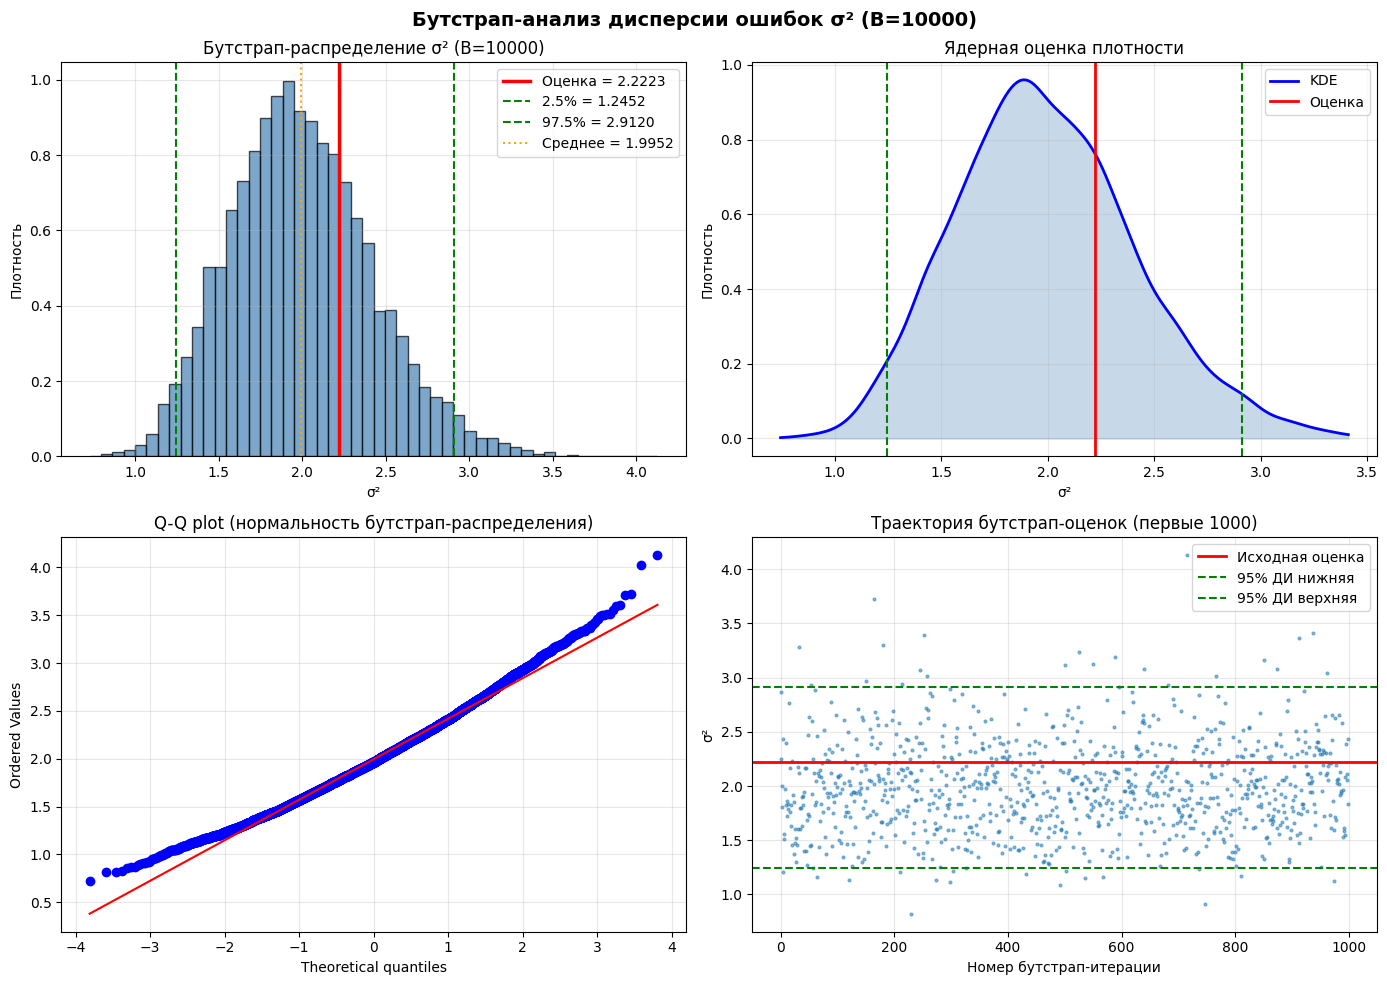


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА
Медиана бутстрапа = 1.964677
Мода (приближ.) = 1.884265
Асимметрия (skewness) = 0.3869
Эксцесс (kurtosis) = 0.1820

Проверка H₀: σ² = 1.5
p-value = 0.1186

✅ Результаты сохранены в 'bootstrap_results.npz'


In [58]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats
import matplotlib.pyplot as plt

# ========== 1. ИСХОДНЫЕ ДАННЫЕ ==========
# Предполагается, что vec уже загружен
X = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)

# ========== 2. ОЦЕНКА МОДЕЛИ НА РЕАЛЬНЫХ ДАННЫХ ==========
model = LinearRegression()
model.fit(X, Y)
y_pred = model.predict(X)

# Остатки и оценка сигма²
e = Y - y_pred
sigma_hat_sq = np.var(e, ddof=1)  # несмещенная оценка
sigma_hat = np.sqrt(sigma_hat_sq)

print("=" * 60)
print("РЕЗУЛЬТАТЫ РЕАЛЬНОЙ МОДЕЛИ")
print("=" * 60)
print(f"n = {n}")
print(f"β₀ = {model.intercept_:.4f}")
print(f"β = {model.coef_}")
print(f"σ̂² = {sigma_hat_sq:.6f}")
print(f"σ̂ = {sigma_hat:.6f}")

# ========== 3. ПАРАМЕТРИЧЕСКИЙ БУТСТРАП ДЛЯ σ² (B=10000) ==========
B = 10000
np.random.seed(123)  # для воспроизводимости

print("\n" + "=" * 60)
print(f"ЗАПУСК БУТСТРАПА (B={B})")
print("=" * 60)

sigma_sq_boot = np.zeros(B)
beta0_boot = np.zeros(B)
beta_boot = np.zeros((B, 5))

for b in range(B):
    # Генерируем Y* из модели с оцененными параметрами
    Y_star = y_pred + np.random.normal(0, sigma_hat, n)
    
    # Оцениваем модель на бутстрап-данных
    model_boot = LinearRegression()
    model_boot.fit(X, Y_star)
    
    # Остатки и их дисперсия
    e_boot = Y_star - model_boot.predict(X)
    sigma_sq_boot[b] = np.var(e_boot, ddof=1)
    
    # Сохраняем коэффициенты (на всякий случай)
    beta0_boot[b] = model_boot.intercept_
    beta_boot[b, :] = model_boot.coef_
    
    # Прогресс
    if (b + 1) % 2000 == 0:
        print(f"  Прогресс: {b+1}/{B} ({100*(b+1)/B:.0f}%)")

# ========== 4. СТАТИСТИКИ БУТСТРАП-РАСПРЕДЕЛЕНИЯ ==========
mean_sigma_sq = np.mean(sigma_sq_boot)
std_sigma_sq = np.std(sigma_sq_boot)
bias = mean_sigma_sq - sigma_hat_sq
mse = np.mean((sigma_sq_boot - sigma_hat_sq)**2)

# Доверительные интервалы
alpha = 0.05
CI_lower = np.percentile(sigma_sq_boot, 100 * alpha/2)
CI_upper = np.percentile(sigma_sq_boot, 100 * (1 - alpha/2))
CI_median_lower = np.percentile(sigma_sq_boot, 100 * alpha/2)
CI_median_upper = np.percentile(sigma_sq_boot, 100 * (1 - alpha/2))

# 90%, 95%, 99% интервалы
CI_90 = (np.percentile(sigma_sq_boot, 5), np.percentile(sigma_sq_boot, 95))
CI_95 = (np.percentile(sigma_sq_boot, 2.5), np.percentile(sigma_sq_boot, 97.5))
CI_99 = (np.percentile(sigma_sq_boot, 0.5), np.percentile(sigma_sq_boot, 99.5))

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ БУТСТРАПА ДЛЯ σ²")
print("=" * 60)
print(f"Точечная оценка σ̂² = {sigma_hat_sq:.6f}")
print(f"Среднее бутстрапа = {mean_sigma_sq:.6f}")
print(f"Стандартная ошибка SE = {std_sigma_sq:.6f}")
print(f"Смещение (bias) = {bias:.6f}")
print(f"MSE = {mse:.6f}")
print(f"\nДоверительные интервалы (перцентильный метод):")
print(f"  90% ДИ: [{CI_90[0]:.6f}, {CI_90[1]:.6f}]")
print(f"  95% ДИ: [{CI_95[0]:.6f}, {CI_95[1]:.6f}]")
print(f"  99% ДИ: [{CI_99[0]:.6f}, {CI_99[1]:.6f}]")

# ========== 5. ТЕОРЕТИЧЕСКИЙ ИНТЕРВАЛ (ДЛЯ СРАВНЕНИЯ) ==========
from scipy.stats import chi2
df = n - 5 - 1  # степени свободы
CI_theor_lower = df * sigma_hat_sq / chi2.ppf(1 - alpha/2, df)
CI_theor_upper = df * sigma_hat_sq / chi2.ppf(alpha/2, df)

print(f"\nТеоретический 95% ДИ (χ²): [{CI_theor_lower:.6f}, {CI_theor_upper:.6f}]")
print(f"Бутстрап 95% ДИ:           [{CI_95[0]:.6f}, {CI_95[1]:.6f}]")

# ========== 6. ВИЗУАЛИЗАЦИЯ ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Гистограмма бутстрап-распределения
axes[0, 0].hist(sigma_sq_boot, bins=50, density=True, alpha=0.7, 
                color='steelblue', edgecolor='black')
axes[0, 0].axvline(sigma_hat_sq, color='red', linewidth=2.5, 
                   label=f'Оценка = {sigma_hat_sq:.4f}')
axes[0, 0].axvline(CI_95[0], color='green', linestyle='--', 
                   label=f'2.5% = {CI_95[0]:.4f}')
axes[0, 0].axvline(CI_95[1], color='green', linestyle='--', 
                   label=f'97.5% = {CI_95[1]:.4f}')
axes[0, 0].axvline(mean_sigma_sq, color='orange', linestyle=':', 
                   label=f'Среднее = {mean_sigma_sq:.4f}')
axes[0, 0].set_xlabel('σ²')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title(f'Бутстрап-распределение σ² (B={B})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Ядерная оценка плотности
from scipy.stats import gaussian_kde
kde = gaussian_kde(sigma_sq_boot)
x_grid = np.linspace(CI_95[0] - 0.5, CI_95[1] + 0.5, 200)
axes[0, 1].plot(x_grid, kde(x_grid), 'b-', linewidth=2, label='KDE')
axes[0, 1].fill_between(x_grid, kde(x_grid), alpha=0.3, color='steelblue')
axes[0, 1].axvline(sigma_hat_sq, color='red', linewidth=2, label='Оценка')
axes[0, 1].axvline(CI_95[0], color='green', linestyle='--', linewidth=1.5)
axes[0, 1].axvline(CI_95[1], color='green', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('σ²')
axes[0, 1].set_ylabel('Плотность')
axes[0, 1].set_title('Ядерная оценка плотности')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Q-Q plot для проверки нормальности
from scipy import stats as ss
ss.probplot(sigma_sq_boot, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot (нормальность бутстрап-распределения)')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Траектория бутстрап-оценок (первые 1000)
axes[1, 1].plot(sigma_sq_boot[:1000], 'o', markersize=2, alpha=0.5)
axes[1, 1].axhline(sigma_hat_sq, color='red', linewidth=2, label='Исходная оценка')
axes[1, 1].axhline(CI_95[0], color='green', linestyle='--', label='95% ДИ нижняя')
axes[1, 1].axhline(CI_95[1], color='green', linestyle='--', label='95% ДИ верхняя')
axes[1, 1].set_xlabel('Номер бутстрап-итерации')
axes[1, 1].set_ylabel('σ²')
axes[1, 1].set_title('Траектория бутстрап-оценок (первые 1000)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Бутстрап-анализ дисперсии ошибок σ² (B={B})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ========== 7. ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА ==========
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
print("=" * 60)
print(f"Медиана бутстрапа = {np.median(sigma_sq_boot):.6f}")
print(f"Мода (приближ.) = {x_grid[np.argmax(kde(x_grid))]:.6f}")
print(f"Асимметрия (skewness) = {ss.skew(sigma_sq_boot):.4f}")
print(f"Эксцесс (kurtosis) = {ss.kurtosis(sigma_sq_boot):.4f}")

# p-value для проверки H₀: σ² = 1.5 (если нужно)
sigma_sq_null = 1.5
p_value = np.mean(sigma_sq_boot >= sigma_sq_null) if sigma_hat_sq < sigma_sq_null else np.mean(sigma_sq_boot <= sigma_sq_null)
print(f"\nПроверка H₀: σ² = {sigma_sq_null}")
print(f"p-value = {p_value:.4f}")

# ========== 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ (опционально) ==========
# Сохраняем бутстрап-оценки в файл
np.savez('bootstrap_results.npz', 
         sigma_sq_boot=sigma_sq_boot,
         beta0_boot=beta0_boot,
         beta_boot=beta_boot,
         sigma_hat_sq=sigma_hat_sq,
         CI_95_lower=CI_95[0],
         CI_95_upper=CI_95[1])

print("\n✅ Результаты сохранены в 'bootstrap_results.npz'")

In [59]:

results = {
    "test": {
        "name": "Тест инверсий на независимость остатков",
        "hypotheses": {
            "H0": "Остатки независимы (случайная последовательность)",
            "H1": "Остатки зависимы (есть автокорреляция)"
        }
    },
    "data": {
        "n_observations": int(n),
        "n_parameters": 6
    },
    "residuals": {
        "mean": round(float(np.mean(e)), 6),
        "std": round(float(np.std(e, ddof=1)), 4),
        "min": round(float(np.min(e)), 4),
        "max": round(float(np.max(e)), 4)
    },
    "inversion_test": {
        "inversions_count_K": int(K),
        "expected_K": round(float(E_K), 4),
        "variance_K": round(float(Var_K), 4),
        "Z_statistic": round(float(Z), 4),
        "p_value": round(float(p_value), 4),
        "alpha": 0.05,
        "Z_critical_95": round(float(stats.norm.ppf(0.975)), 4),
        "significant": bool(p_value < 0.05),
        "conclusion": "Остатки зависимы (H0 отвергается)" if p_value < 0.05 else "Остатки независимы (H0 не отвергается)"
    },
}

with open('1e.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

## Проверка нормальности распределения ошибок
### Критерий Колмогорова-Смирнова с параметрическим бутстрапом

### 1. Модель и остатки

**Линейная регрессия:**
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$$

**Предсказанные значения:**
$$\hat{y}_i = \hat{\beta}_0 + \sum_{k=1}^{5} \hat{\beta}_k x_{ik}$$

**Остатки:**
$$e_i = y_i - \hat{y}_i, \quad i = 1, 2, \ldots, n$$

**Стандартизованные остатки:**
$$e_i^* = \frac{e_i - \bar{e}}{\hat{\sigma}_e}, \quad \bar{e} = \frac{1}{n}\sum_{i=1}^{n} e_i, \quad \hat{\sigma}_e = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n} (e_i - \bar{e})^2}$$

### 2. Гипотезы

$$H_0: e_i \sim \mathcal{N}(0, \sigma^2) \quad \text{(ошибки распределены нормально)}$$
$$H_1: e_i \not\sim \mathcal{N}(0, \sigma^2) \quad \text{(ошибки не распределены нормально)}$$

### 3. Статистика Колмогорова-Смирнова

**Эмпирическая функция распределения:**
$$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbb{I}(e_{(i)}^* \leq x) = \frac{i}{n}, \quad \text{для } e_{(i)}^* \leq x < e_{(i+1)}^*$$

где $e_{(1)}^* \leq e_{(2)}^* \leq \ldots \leq e_{(n)}^*$ — порядковые статистики.

**Теоретическая функция распределения:**
$$\Phi(x) = \int_{-\infty}^{x} \frac{1}{\sqrt{2\pi}} e^{-\frac{t^2}{2}} dt$$

**Статистика Колмогорова:**
$$D_n = \sup_{x} |F_n(x) - \Phi(x)|$$

**Вычисление на отсортированных данных:**
$$D_n^+ = \max_{1 \leq i \leq n} \left( \Phi(e_{(i)}^*) - \frac{i}{n} \right)$$

$$D_n^- = \max_{1 \leq i \leq n} \left( \frac{i}{n} - \Phi(e_{(i)}^*) \right)$$

$$D_n = \max(D_n^+, D_n^-)$$

**Статистика с поправкой Колмогорова:**
$$\delta = \sqrt{n} \cdot D_n$$

### 4. Параметрический бутстрап

**Алгоритм:**
1. Оцениваем параметры $\hat{\boldsymbol{\beta}}, \hat{\sigma}$ по исходным данным
2. Для $b = 1, 2, \ldots, B$:
   - Генерируем новые данные: $\boldsymbol{\xi}^{(b)} \sim U[-1, 1]$
   - Вычисляем: $\boldsymbol{\eta}^{(b)} = \mathbf{X}^{(b)}\boldsymbol{\beta} + \boldsymbol{\varepsilon}^{(b)}, \quad \varepsilon_i^{(b)} \sim \mathcal{N}(0, \hat{\sigma}^2)$
   - Оцениваем модель: $\hat{\boldsymbol{\beta}}^{(b)}$
   - Вычисляем остатки и статистику: $\delta^{(b)} = \sqrt{n} \cdot D_n^{(b)}$

**Бутстрап-распределение:**
$$\{\delta^{(1)}, \delta^{(2)}, \ldots, \delta^{(B)}\}$$

### 5. p-value

**Определение:**
$$p = P(\delta \geq \delta_{набл} \mid H_0) = \frac{1}{B} \sum_{b=1}^{B} \mathbb{I}(\delta^{(b)} \geq \delta_{набл})$$

**Критическое значение:**
$$\delta_{крит} = F_{\delta}^{-1}(1 - \alpha) = \text{перцентиль}_{1-\alpha}\{\delta^{(b)}\}$$

### 6. Правило принятия решения

$$\text{Если } p > \alpha \Rightarrow \text{нет оснований отвергнуть } H_0 \text{ (ошибки нормальны)}$$
$$\text{Если } p \leq \alpha \Rightarrow \text{отвергаем } H_0 \text{ (ошибки не нормальны)}$$

где $\alpha = 0.05$ — уровень значимости.

### 7. Свойства статистики Колмогорова

**Асимптотическое распределение (при $H_0$):**
$$\lim_{n \to \infty} P(\sqrt{n} D_n \leq x) = 1 - 2 \sum_{k=1}^{\infty} (-1)^{k-1} e^{-2k^2 x^2}$$

**Критические значения для $\alpha = 0.05$:**
$$\delta_{крит} \approx 1.358 \quad \text{(асимптотическое)}$$

In [60]:
X = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)

model = LinearRegression()
model.fit(X, Y)
y_pred = model.predict(X)

e = Y - y_pred
e_std = (e - np.mean(e)) / np.std(e, ddof=1)
e_sort = np.sort(e_std)

otcl = np.arange(1, n+1) / n

phi = stats.norm.cdf(e_sort)

D_plus = np.max(phi - otcl)
D_minus = np.max(otcl - phi)
D = max(D_plus, D_minus)
delta_pred = np.sqrt(n) * D


B = 10000
delta_sim = np.zeros(B)


for b in range(B):
    ksi_sim = np.random.uniform(-1, 1, (n, 5))
    mean_sim = 2 + 3*ksi_sim[:, 0] - 2*ksi_sim[:, 1] + ksi_sim[:, 2] + ksi_sim[:, 3] - ksi_sim[:, 4]
    eta_sim = np.random.normal(mean_sim, 1.5)
    
    vec_sim = np.concatenate([ksi_sim, eta_sim.reshape(-1, 1)], axis=1)
    Y_sim = vec_sim[:, 5]
    X_sim = vec_sim[:, 0:5]
    
    model_sim = LinearRegression()
    model_sim.fit(X_sim, Y_sim)
    y_pred_sim = model_sim.predict(X_sim)
    
    e_sim = Y_sim - y_pred_sim
    e_sim_std = (e_sim - np.mean(e_sim)) / np.std(e_sim, ddof=1)
    e_sim_sort = np.sort(e_sim_std)
    
    phi_sim = stats.norm.cdf(e_sim_sort)
    otcl_sim = np.arange(1, n+1) / n
    D_sim = np.max(np.abs(phi_sim - otcl_sim))
    delta_sim[b] = np.sqrt(n) * D_sim
    
    if (b+1) % 2000 == 0:
        print(f"Прогресс: {b+1}/{B}")

p_value = np.mean(delta_sim >= delta_pred)

print(f"\nРезультаты (B={B}):")
print(f"Исходная статистика δ = {delta_pred:.4f}")
print(f"Критическое значение (95%): {np.percentile(delta_sim, 95):.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
if p_value > alpha:
    print(f"\n Нет оснований отвергнуть H₀ (p={p_value:.4f} > {alpha})")
    print("   Ошибки распределены НОРМАЛЬНО")
else:
    print(f"\n Отвергаем H₀ (p={p_value:.4f} ≤ {alpha})")
    print("   Ошибки НЕ распределены нормально")


Прогресс: 2000/10000
Прогресс: 4000/10000
Прогресс: 6000/10000
Прогресс: 8000/10000
Прогресс: 10000/10000

Результаты (B=10000):
Исходная статистика δ = 0.5557
Критическое значение (95%): 0.8341
p-value = 0.4536

 Нет оснований отвергнуть H₀ (p=0.4536 > 0.05)
   Ошибки распределены НОРМАЛЬНО


In [61]:
results = {
    "test": {
        "name": "Критерий Колмогорова-Смирнова с параметрическим бутстрапом",
        "type": "Проверка нормальности распределения ошибок",
        "hypotheses": {
            "H0": "Ошибки имеют нормальное распределение N(0, σ²)",
            "H1": "Ошибки не имеют нормального распределения"
        }
    },
    "data": {
        "sample_size": int(n),
        "parameters_count": 6,
        "degrees_of_freedom": int(n - 6)
    },
    "model": {
        "R_squared": round(float(model.score(X, Y)), 4),
        "coefficients": {
            f"β{i}": round(float(b), 4) 
            for i, b in enumerate(np.append(model.intercept_, model.coef_))
        }
    },
    "residuals": {
        "mean": round(float(np.mean(e)), 6),
        "std": round(float(np.std(e, ddof=1)), 4),
        "skewness": round(float(stats.skew(e)), 4),
        "kurtosis": round(float(stats.kurtosis(e)), 4),
        "min": round(float(np.min(e)), 4),
        "max": round(float(np.max(e)), 4)
    },
    "kolmogorov_smirnov": {
        "statistic_D": round(float(D), 4),
        "statistic_delta": round(float(delta_pred), 4),
        "D_plus": round(float(D_plus), 4),
        "D_minus": round(float(D_minus), 4)
    },
    "bootstrap": {
        "method": "Параметрический бутстрап",
        "B": B,
        "delta_observed": round(float(delta_pred), 4),
        "delta_critical_95": round(float(np.percentile(delta_sim, 95)), 4),
        "delta_mean": round(float(np.mean(delta_sim)), 4),
        "delta_std": round(float(np.std(delta_sim)), 4),
        "p_value": round(float(p_value), 4),
        "alpha": 0.05,
        "significant": bool(p_value <= 0.05),
        "conclusion": (
            "Ошибки распределены НОРМАЛЬНО (H₀ не отвергается)" 
            if p_value > 0.05 
            else "Ошибки НЕ распределены нормально (H₀ отвергается)"
        )
    },
    "bootstrap_distribution": {
        "percentiles": {
            "2.5%": round(float(np.percentile(delta_sim, 2.5)), 4),
            "25%": round(float(np.percentile(delta_sim, 25)), 4),
            "50%": round(float(np.percentile(delta_sim, 50)), 4),
            "75%": round(float(np.percentile(delta_sim, 75)), 4),
            "95%": round(float(np.percentile(delta_sim, 95)), 4),
            "97.5%": round(float(np.percentile(delta_sim, 97.5)), 4)
        }
    }
}

with open('1f.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


In [62]:
# g) Исследование на выбосы

In [63]:
import numpy as np
from sklearn.linear_model import LinearRegression

X_full = vec[:, 0:5]
Y_full = vec[:, 5]

model_full = LinearRegression()
model_full.fit(X_full, Y_full)
R2_full = model_full.score(X_full, Y_full)

X = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)

Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = np.all((X >= lower_bound) & (X <= upper_bound), axis=1)

Xn = X[mask]
Yn = Y[mask]


print(f"Исходная выборка: n = {n}")
print(f"После фильтрации:  n = {len(Yn)}")
print(f"Удалено выбросов:  {n - len(Yn)}")

# модель без выбросов
model_clean = LinearRegression()
model_clean.fit(Xn, Yn)
yn_pred = model_clean.predict(Xn)

# R^2
TSS_clean = np.sum((Yn - np.mean(Yn))**2)
RSS_clean = np.sum((Yn - yn_pred)**2)
R2_clean = 1 - RSS_clean / TSS_clean

print(f"\nR² (исходная): {R2_full:.4f}")
print(f"R² (без выбросов): {R2_clean:.4f}")
print(f"Изменение R²: {R2_clean - R2_full:+.4f}")


beta_full = np.append(model_full.intercept_, model_full.coef_)
beta_clean = np.append(model_clean.intercept_, model_clean.coef_)


Исходная выборка: n = 50
После фильтрации:  n = 50
Удалено выбросов:  0

R² (исходная): 0.6404
R² (без выбросов): 0.6404
Изменение R²: +0.0000


In [64]:

results = {
    "outlier_removal": {
        "method": "IQR (межквартильный размах) с множителем 1.5",
        "original_n": int(n),
        "removed_outliers_X": int(n -len(Yn)),
    },
    "models_comparison": {
        "original": {
            "R2": round(float(R2_full), 4),
            "intercept": round(float(model_full.intercept_), 4),
            "coefficients": model_full.coef_.tolist()
        },
        "without_outliers": {
            "R2": round(float(R2_clean), 4),
            "intercept": round(float(model_clean.intercept_), 4),
            "coefficients": model_clean.coef_.tolist()
        },
        "R2_change": round(float(R2_clean - R2_full), 4)
    }
}

with open('1g.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


## Кросс-валидация Leave-One-Out (LOOCV)

### Идея метода
Поочередно исключаем одно наблюдение, обучаем модель на оставшихся n-1 наблюдениях и проверяем качество предсказания исключенного наблюдения.

### Алгоритм
Для каждого $i = 1, 2, \ldots, n$:

1. **Исключаем i-е наблюдение:**
   $$\mathbf{X}_{(-i)} = \mathbf{X} \setminus \{i\text{-я строка}\}$$
   $$\mathbf{Y}_{(-i)} = \mathbf{Y} \setminus \{y_i\}$$

2. **Оцениваем модель без i-го наблюдения:**
   $$\hat{\boldsymbol{\beta}}_{(-i)} = (\mathbf{X}_{(-i)}^T\mathbf{X}_{(-i)})^{-1}\mathbf{X}_{(-i)}^T\mathbf{Y}_{(-i)}$$

3. **Предсказываем i-е наблюдение:**
   $$\hat{y}_{(i)} = \mathbf{x}_i^T\hat{\boldsymbol{\beta}}_{(-i)}$$
   где $\mathbf{x}_i$ — i-я строка матрицы $\mathbf{X}$.

4. **Вычисляем ошибку предсказания:**
   $$e_{(i)} = y_i - \hat{y}_{(i)}$$

### Статистика PRESS
$$CVSS_i = e_{(i)}^2 = (y_i - \hat{y}_{(i)})^2$$

$$PRESS = CVSS = \sum_{i=1}^{n} CVSS_i = \sum_{i=1}^{n} (y_i - \hat{y}_{(i)})^2$$

### Общая сумма квадратов
$$TSS = \sum_{i=1}^{n} (y_i - \bar{y})^2, \quad \bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

### R² кросс-валидации
$$R_{CV}^2 = 1 - \frac{PRESS}{TSS} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_{(i)})^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

### Свойства $R_{CV}^2$
- $R_{CV}^2 \leq R^2$ (всегда не больше обычного R²)
- Может быть отрицательным!
- Если $R_{CV}^2 < 0$ → модель предсказывает хуже, чем простое среднее $\bar{y}$



### Интерпретация $R_{CV}^2$

| Значение | Интерпретация |
|----------|---------------|
| $R_{CV}^2 > 0.7$ | Отличная предсказательная способность |
| $0.5 < R_{CV}^2 \leq 0.7$ | Хорошая предсказательная способность |
| $0.3 < R_{CV}^2 \leq 0.5$ | Средняя предсказательная способность |
| $0 < R_{CV}^2 \leq 0.3$ | Слабая предсказательная способность |
| $R_{CV}^2 \leq 0$ | Модель непредсказательна! |

In [65]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)

TSS = np.sum((Y - np.mean(Y))**2)

CVSS = 0
predictions = np.zeros(n)

for i in range(n):
    Xi = np.delete(X, i, axis=0)
    Yi = np.delete(Y, i)
    
    model = LinearRegression()
    model.fit(Xi, Yi)
    
    yi_pred = model.predict(X[i:i+1])[0]
    predictions[i] = yi_pred
    
    CVSSi = (Y[i] - yi_pred)**2
    CVSS += CVSSi

Rcv2 = 1 - CVSS / TSS

model_full = LinearRegression()
model_full.fit(X, Y)
R2_full = model_full.score(X, Y)

print(f"TSS = {TSS:.4f}")
print(f"PRESS (CVSS) = {CVSS:.4f}")
print(f"R²(обычный) = {R2_full:.4f}")
print(f"R²(LOOCV)   = {Rcv2:.4f}")

if Rcv2 > 0:
    print(f"\nМодель имеет предсказательную способность")
else:
    print(f"\nМодель НЕ имеет предсказательной способности (R²_LOOCV < 0)")

TSS = 302.8171
PRESS (CVSS) = 139.0156
R²(обычный) = 0.6404
R²(LOOCV)   = 0.5409

Модель имеет предсказательную способность


In [66]:
if Rcv2 > 0.7:
    quality = "Отличная"
elif Rcv2 > 0.5:
    quality = "Хорошая"
elif Rcv2 > 0.3:
    quality = "Средняя"
elif Rcv2 > 0:
    quality = "Слабая"
else:
    quality = "Неудовлетворительная (модель непредсказательна)"

results = {
    "cross_validation": {
        "method": "Leave-One-Out Cross-Validation (LOOCV)",
        "description": "Поочередное исключение одного наблюдения",
        "n_observations": int(n),
        "n_folds": int(n)
    },
    "sums_of_squares": {
        "TSS_total": round(float(TSS), 4),
        "PRESS_CVSS": round(float(CVSS), 4),
        "TSS_formula": "Σ(y_i - ȳ)²",
        "PRESS_formula": "Σ(y_i - ŷ_(i))²"
    },
    "r_squared": {
        "R2_ordinary": round(float(R2_full), 4),
        "R2_LOOCV": round(float(Rcv2), 4),
        "R2_difference": round(float(R2_full - Rcv2), 4),
        "overfitting_assessment": (
            "Переобучение" if R2_full - Rcv2 > 0.1 
            else "Небольшое переобучение" if R2_full - Rcv2 > 0.05 
            else "Модель стабильна"
        )
    },
    "prediction_quality": {
        "R2_LOOCV": round(float(Rcv2), 4),
        "quality": quality,
        "has_predictive_power": bool(Rcv2 > 0),
        "interpretation": (
            "Модель предсказывает лучше, чем простое среднее" if Rcv2 > 0 
            else "Модель предсказывает ХУЖЕ, чем простое среднее!"
        )
    },

    "predictions": {
        "y_pred_min": round(float(np.min(predictions)), 4),
        "y_pred_max": round(float(np.max(predictions)), 4),
        "y_pred_mean": round(float(np.mean(predictions)), 4)
    }
}

with open('1h.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

In [67]:
# Адекватность 

In [68]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats
import json

X = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)
p = 6

model = LinearRegression()
model.fit(X, Y)
y_pred = model.predict(X)

sigma2 = np.sum((Y - y_pred)**2) / (n - p)

point_index = 0
x_point = X[point_index:point_index+1]

true_mean = 2 + 3*x_point[0,0] - 2*x_point[0,1] + x_point[0,2] + x_point[0,3] - x_point[0,4]
k = 5
Y_repeated = np.random.normal(true_mean, 1.5, k)

y_pred_point = model.predict(x_point)[0]


rm5 = np.random.choice(n, k, replace=False)
Xrm = np.delete(X, rm5, axis=0)
Yrm = np.delete(Y, rm5)

model_rm = LinearRegression()
model_rm.fit(Xrm, Yrm)
y_pred_rm = model_rm.predict(Xrm)

RSS_rm = np.sum((Yrm - y_pred_rm)**2)

sigma_repeated = np.sum((Y_repeated - np.mean(Y_repeated))**2) / (k - 1)

df1 = k - 1
df2 = n - k - p

F_stat = (RSS_rm / df2) / sigma_repeated

p_value = stats.f.sf(F_stat, df2, df1)



alpha = 0.05
if p_value > alpha:
    print(f"\n Модель АДЕКВАТНА (p={p_value:.4f} > {alpha})")
else:
    print(f"\n Модель НЕАДЕКВАТНА (p={p_value:.4f} ≤ {alpha})")


 Модель АДЕКВАТНА (p=0.6672 > 0.05)


In [69]:

results = {
    "adequacy_test": {
        "name": "Проверка адекватности регрессии",
        "method": "F-тест с повторными измерениями",
        "hypotheses": {
            "H0": "Модель адекватна",
            "H1": "Модель неадекватна"
        }
    },
    "point": {
        "index": int(point_index),
        "coordinates": {
            "xi_1": round(float(x_point[0, 0]), 4),
            "xi_2": round(float(x_point[0, 1]), 4),
            "xi_3": round(float(x_point[0, 2]), 4),
            "xi_4": round(float(x_point[0, 3]), 4),
            "xi_5": round(float(x_point[0, 4]), 4)
        },
        "true_mean": round(float(true_mean), 4),
        "predicted_value": round(float(y_pred_point), 4),
        "prediction_error": round(float(y_pred_point - true_mean), 4)
    },
    "repeated_measurements": {
        "k": int(k),
        "values": [round(float(y), 4) for y in Y_repeated],
        "mean": round(float(np.mean(Y_repeated)), 4),
        "variance": round(float(sigma_repeated), 4),
        "std": round(float(np.sqrt(sigma_repeated)), 4)
    },
    "model": {
        "type": "Линейная регрессия",
        "n_observations": int(n),
        "n_parameters": int(p),
        "degrees_of_freedom": int(n - p),
        "intercept": round(float(model.intercept_), 4),
        "coefficients": [round(float(b), 4) for b in model.coef_],
        "sigma2_MSE": round(float(sigma2), 4)
    },
    "removed_points": {
        "indices": rm5.tolist(),
        "count": int(k),
        "X_removed": X[rm5].tolist(),
        "Y_removed": [round(float(y), 4) for y in Y[rm5]]
    },
    "reduced_model": {
        "n_observations": int(len(Xrm)),
        "RSS": round(float(RSS_rm), 4),
        "intercept": round(float(model_rm.intercept_), 4),
        "coefficients": [round(float(b), 4) for b in model_rm.coef_]
    },
    "f_test": {
        "F_statistic": round(float(F_stat), 4),
        "degrees_of_freedom": {
            "df1_numerator": int(df1),
            "df2_denominator": int(df2)
        },
        "p_value": round(float(p_value), 4),
        "alpha": float(alpha),
        "F_critical": round(float(stats.f.ppf(1 - alpha, df2, df1)), 4),
        "significant": bool(p_value <= alpha),
        "conclusion": (
            "Модель АДЕКВАТНА" if p_value > alpha 
            else "Модель НЕАДЕКВАТНА"
        )
    },
    "variance_comparison": {
        "sigma2_model_MSE": round(float(sigma2), 4),
        "sigma2_repeated": round(float(sigma_repeated), 4),
        "ratio": round(float(sigma2 / sigma_repeated), 4)
    }
}

with open('1i.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


In [70]:
X_full = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)

# удаляем ξ₄ 
X_reduced = np.delete(X_full, 3, axis=1)


model_full = LinearRegression()
model_full.fit(X_full, Y)
y_pred_full = model_full.predict(X_full)

beta_full = np.append(model_full.intercept_, model_full.coef_)

p_full = 6
X_int_full = np.column_stack([np.ones(n), X_full])
X_inv_full = np.linalg.inv(X_int_full.T @ X_int_full)
sigma2_full = np.sum((Y - y_pred_full)**2) / (n - p_full)
se_full = np.sqrt(sigma2_full * np.diag(X_inv_full))
t_full = beta_full / se_full
p_values_full = 2 * stats.t.sf(np.abs(t_full), df=n - p_full)

TSS = np.sum((Y - np.mean(Y))**2)
RSS_full = np.sum((Y - y_pred_full)**2)
R2_full = 1 - RSS_full / TSS
R2_adj_full = 1 - (1 - R2_full) * (n - 1) / (n - p_full)

F_full = (R2_full / (p_full - 1)) / ((1 - R2_full) / (n - p_full))
p_F_full = stats.f.sf(F_full, p_full - 1, n - p_full)

print("\nПолная модель: η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₄ξ₄ + β₅ξ₅")
print(f"{'Коэфф.':<8} {'Значение':<12} {'SE':<12} {'t-стат':<12} {'p-value':<12} {'Значим':<10}")
for i, (b, se, t, p) in enumerate(zip(beta_full, se_full, t_full, p_values_full)):
    significant = "Да" if p < 0.05 else "Нет"
    print(f"β{i:<7} {b:<12.4f} {se:<12.4f} {t:<12.4f} {p:<12.4f} {significant:<10}")

print(f"\nR² = {R2_full:.4f}")
print(f"R² скорр. = {R2_adj_full:.4f}")
print(f"F-статистика = {F_full:.4f}, p-value = {p_F_full:.6f}")

model_reduced = LinearRegression()
model_reduced.fit(X_reduced, Y)
y_pred_reduced = model_reduced.predict(X_reduced)

beta_reduced = np.append(model_reduced.intercept_, model_reduced.coef_)

p_reduced = 5
X_int_reduced = np.column_stack([np.ones(n), X_reduced])
X_inv_reduced = np.linalg.inv(X_int_reduced.T @ X_int_reduced)
sigma2_reduced = np.sum((Y - y_pred_reduced)**2) / (n - p_reduced)
se_reduced = np.sqrt(sigma2_reduced * np.diag(X_inv_reduced))
t_reduced = beta_reduced / se_reduced
p_values_reduced = 2 * stats.t.sf(np.abs(t_reduced), df=n - p_reduced)

RSS_reduced = np.sum((Y - y_pred_reduced)**2)
R2_reduced = 1 - RSS_reduced / TSS
R2_adj_reduced = 1 - (1 - R2_reduced) * (n - 1) / (n - p_reduced)

F_reduced = (R2_reduced / (p_reduced - 1)) / ((1 - R2_reduced) / (n - p_reduced))
p_F_reduced = stats.f.sf(F_reduced, p_reduced - 1, n - p_reduced)

print(f"\nРедуцированная модель: η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₅ξ₅")
print(f"{'Коэфф.':<8} {'Значение':<12} {'SE':<12} {'t-стат':<12} {'p-value':<12} {'Значим':<10}")

names_reduced = ['β0', 'β1', 'β2', 'β3', 'β5']
for i, (name, b, se, t, p) in enumerate(zip(names_reduced, beta_reduced, se_reduced, t_reduced, p_values_reduced)):
    significant = "Да" if p < 0.05 else "Нет"
    print(f"{name:<7} {b:<12.4f} {se:<12.4f} {t:<12.4f} {p:<12.4f} {significant:<10}")

print(f"\nR² = {R2_reduced:.4f}")
print(f"R² скорр. = {R2_adj_reduced:.4f}")
print(f"F-статистика = {F_reduced:.4f}, p-value = {p_F_reduced:.6f}")

# СРАВНЕНИЕ МОДЕЛЕЙ
print(f"{'Показатель':<25} {'Полная':<15} {'Редуцированная':<15} {'Изменение':<15}")
print(f"{'Число признаков':<25} {5:<15} {4:<15} {-1:<15}")
print(f"{'Число параметров p':<25} {p_full:<15} {p_reduced:<15} {p_reduced-p_full:<15}")
print(f"{'R²':<25} {R2_full:<15.4f} {R2_reduced:<15.4f} {R2_reduced-R2_full:<15.4f}")
print(f"{'R² скорректированный':<25} {R2_adj_full:<15.4f} {R2_adj_reduced:<15.4f} {R2_adj_reduced-R2_adj_full:<15.4f}")
print(f"{'RSS':<25} {RSS_full:<15.4f} {RSS_reduced:<15.4f} {RSS_reduced-RSS_full:<15.4f}")
print(f"{'MSE':<25} {sigma2_full:<15.4f} {sigma2_reduced:<15.4f} {sigma2_reduced-sigma2_full:<15.4f}")

F_remove = ((RSS_reduced - RSS_full) / 1) / (RSS_full / (n - p_full))
p_remove = stats.f.sf(F_remove, 1, n - p_full)

print(f"\nF-тест на значимость удаленной переменной ξ₄:")
print(f"F = {F_remove:.4f}")
print(f"p-value = {p_remove:.4f}")
print(f"Удаление {'ОПРАВДАНО' if p_remove > 0.05 else 'НЕОПРАВДАНО'} (p {'>' if p_remove > 0.05 else '≤'} 0.05)")

# Вывод
if R2_adj_reduced >= R2_adj_full:
    print(f"\n Редуцированная модель ЛУЧШЕ (R²_adj выше)")
else:
    print(f"\n Полная модель имеет более высокий R²_adj")


Полная модель: η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₄ξ₄ + β₅ξ₅
Коэфф.   Значение     SE           t-стат       p-value      Значим    
β0       1.9699       0.2259       8.7205       0.0000       Да        
β1       2.9485       0.4034       7.3098       0.0000       Да        
β2       -2.1777      0.4033       -5.4000      0.0000       Да        
β3       0.5454       0.3814       1.4301       0.1597       Нет       
β4       0.3370       0.3732       0.9032       0.3713       Нет       
β5       -1.0800      0.3869       -2.7911      0.0077       Да        

R² = 0.6404
R² скорр. = 0.5995
F-статистика = 15.6717, p-value = 0.000000

Редуцированная модель: η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₅ξ₅
Коэфф.   Значение     SE           t-стат       p-value      Значим    
β0      1.9927       0.2240       8.8952       0.0000       Да        
β1      2.8737       0.3940       7.2943       0.0000       Да        
β2      -2.1443      0.4008       -5.3505      0.0000       Да        
β3      0.4931     

In [71]:
results = {
    "model_comparison": {
        "description": "Сравнение полной и редуцированной моделей",
        "removed_variable": "ξ₄",
        "removal_reason": "Наименее значимый коэффициент в полной модели"
    },
    "full_model": {
        "equation": "η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₄ξ₄ + β₅ξ₅",
        "n_observations": int(n),
        "n_parameters": int(p_full),
        "degrees_of_freedom": int(n - p_full),
        "coefficients": {
            f"β{i}": {
                "estimate": round(float(beta_full[i]), 4),
                "standard_error": round(float(se_full[i]), 4),
                "t_statistic": round(float(t_full[i]), 4),
                "p_value": round(float(p_values_full[i]), 4),
                "significant": bool(p_values_full[i] < 0.05)
            }
            for i in range(len(beta_full))
        },
        "goodness_of_fit": {
            "R_squared": round(float(R2_full), 4),
            "R_squared_adjusted": round(float(R2_adj_full), 4),
            "RSS": round(float(RSS_full), 4),
            "MSE": round(float(sigma2_full), 4),
            "F_statistic": round(float(F_full), 4),
            "F_p_value": round(float(p_F_full), 6)
        }
    },
    "reduced_model": {
        "equation": "η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₅ξ₅",
        "n_observations": int(n),
        "n_parameters": int(p_reduced),
        "degrees_of_freedom": int(n - p_reduced),
        "coefficients": {
            name: {
                "estimate": round(float(beta_reduced[i]), 4),
                "standard_error": round(float(se_reduced[i]), 4),
                "t_statistic": round(float(t_reduced[i]), 4),
                "p_value": round(float(p_values_reduced[i]), 4),
                "significant": bool(p_values_reduced[i] < 0.05)
            }
            for i, name in enumerate(names_reduced)
        },
        "goodness_of_fit": {
            "R_squared": round(float(R2_reduced), 4),
            "R_squared_adjusted": round(float(R2_adj_reduced), 4),
            "RSS": round(float(RSS_reduced), 4),
            "MSE": round(float(sigma2_reduced), 4),
            "F_statistic": round(float(F_reduced), 4),
            "F_p_value": round(float(p_F_reduced), 6)
        }
    },
    "comparison_metrics": {
        "features_count": {
            "full": 5,
            "reduced": 4,
            "change": -1
        },
        "parameters_count": {
            "full": int(p_full),
            "reduced": int(p_reduced),
            "change": int(p_reduced - p_full)
        },
        "R_squared": {
            "full": round(float(R2_full), 4),
            "reduced": round(float(R2_reduced), 4),
            "change": round(float(R2_reduced - R2_full), 4)
        },
        "R_squared_adjusted": {
            "full": round(float(R2_adj_full), 4),
            "reduced": round(float(R2_adj_reduced), 4),
            "change": round(float(R2_adj_reduced - R2_adj_full), 4)
        },
        "RSS": {
            "full": round(float(RSS_full), 4),
            "reduced": round(float(RSS_reduced), 4),
            "change": round(float(RSS_reduced - RSS_full), 4)
        },
        "MSE": {
            "full": round(float(sigma2_full), 4),
            "reduced": round(float(sigma2_reduced), 4),
            "change": round(float(sigma2_reduced - sigma2_full), 4)
        }
    },
    "f_test_for_removed_variable": {
        "tested_variable": "ξ₄",
        "null_hypothesis": "H₀: β₄ = 0 (удаление оправдано)",
        "alternative_hypothesis": "H₁: β₄ ≠ 0 (удаление неоправдано)",
        "F_statistic": round(float(F_remove), 4),
        "degrees_of_freedom": {
            "df1": 1,
            "df2": int(n - p_full)
        },
        "p_value": round(float(p_remove), 4),
        "alpha": 0.05,
        "removal_justified": bool(p_remove > 0.05),
        "conclusion": (
            "Удаление ОПРАВДАНО (ξ₄ незначима)" 
            if p_remove > 0.05 
            else "Удаление НЕОПРАВДАНО (ξ₄ значима)"
        )
    },
    "best_model": {
        "criterion": "Скорректированный R²",
        "winner": (
            "Редуцированная модель" 
            if R2_adj_reduced >= R2_adj_full 
            else "Полная модель"
        ),
        "reason": (
            f"R²_adj редуцированной ({R2_adj_reduced:.4f}) >= R²_adj полной ({R2_adj_full:.4f})"
            if R2_adj_reduced >= R2_adj_full
            else f"R²_adj полной ({R2_adj_full:.4f}) > R²_adj редуцированной ({R2_adj_reduced:.4f})"
        )
    }
}

with open('1j.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)


## Сравнение регрессий бутстрапом

### Гипотезы для каждого коэффициента:
$$H_0: \beta_j^{full} = \beta_j^{reduced}$$
$$H_1: \beta_j^{full} \neq \beta_j^{reduced}$$

### Статистика:
$$\Delta_j = \hat{\beta}_j^{full} - \hat{\beta}_j^{reduced}$$

### Параметрический бутстрап:
1. Генерируем $\mathbf{Y}^* = \mathbf{X}\hat{\boldsymbol{\beta}} + \boldsymbol{\varepsilon}^*$, $\varepsilon_i^* \sim N(0, \hat{\sigma}^2)$
2. Оцениваем обе модели на $(\mathbf{X}, \mathbf{Y}^*)$
3. Вычисляем $\Delta_j^{*(b)} = \hat{\beta}_j^{full*(b)} - \hat{\beta}_j^{reduced*(b)}$
4. Повторяем $B$ раз

### Доверительный интервал (перцентильный):
$$CI_{95\%}(\Delta_j) = [\Delta_j^{*(\alpha/2)}, \Delta_j^{*(1-\alpha/2)}]$$

### p-value:
$$p_j = 2 \cdot \min\left(\frac{1}{B}\sum_{b=1}^{B} \mathbb{I}(\Delta_j^{*(b)} \geq 0), \frac{1}{B}\sum_{b=1}^{B} \mathbb{I}(\Delta_j^{*(b)} \leq 0)\right)$$

### Правило:
Если $0 \notin CI_{95\%}$ или $p < 0.05$ → разница значима

In [72]:
X = vec[:, 0:5]
Y = vec[:, 5]
n = len(Y)

# полная модель
model_full = LinearRegression()
model_full.fit(X, Y)
y_pred_full = model_full.predict(X)
RSS1 = np.sum((Y - y_pred_full)**2)

X_reduced = np.delete(X, 3, axis=1)
model_reduced = LinearRegression()
model_reduced.fit(X_reduced, Y)
y_pred_reduced = model_reduced.predict(X_reduced)
RSS0 = np.sum((Y - y_pred_reduced)**2)

h_obs = RSS0 - RSS1
print(f"RSS (полная):     {RSS1:.4f}")
print(f"RSS (редуцированная): {RSS0:.4f}")
print(f"h = RSS0 - RSS1 = {h_obs:.4f}")
print(f"\nH₀: h = 0 (модели не различаются)")
print(f"H₁: h > 0 (полная модель лучше)")

# непараметрический бутстрап
B = 10000

h_boot = np.zeros(B)

for b in range(B):
    indices = np.random.choice(n, n, replace=True)
    X_boot = X[indices]
    Y_boot = Y[indices]
    
    # полная модель на бутстрап-выборке
    model_full_b = LinearRegression()
    model_full_b.fit(X_boot, Y_boot)
    y_pred_full_b = model_full_b.predict(X_boot)
    RSS1_boot = np.sum((Y_boot - y_pred_full_b)**2)
    
    # редуцированная модель на бутстрап-выборке
    X_boot_reduced = np.delete(X_boot, 3, axis=1)
    model_red_b = LinearRegression()
    model_red_b.fit(X_boot_reduced, Y_boot)
    y_pred_red_b = model_red_b.predict(X_boot_reduced)
    RSS0_boot = np.sum((Y_boot - y_pred_red_b)**2)
    
    h_boot[b] = RSS0_boot - RSS1_boot
    
    if (b+1) % 2000 == 0:
        print(f"Прогресс: {b+1}/{B}")

print(f"\nБутстрап-распределение h*:")
print(f"  Среднее: {np.mean(h_boot):.4f}")
print(f"  Стд:     {np.std(h_boot):.4f}")
print(f"  Мин:     {np.min(h_boot):.4f}")
print(f"  Макс:    {np.max(h_boot):.4f}")

h_boot_sorted = np.sort(h_boot)


# delta* = h* - h_obs
delta_star = h_boot - h_obs

delta_sorted = np.sort(delta_star)

# delta_(50) — нижняя граница (α перцентиль) h > 0 -> правостронний доверительный интервал
# delta_(9950) — верхняя граница (1-α перцентиль)
lower_idx = int(0.05 * B)
upper_idx = int(0.95 * B)

delta_lower = delta_sorted[lower_idx]
delta_upper = delta_sorted[upper_idx]

# h ∈ [h_obs - delta_upper, h_obs - delta_lower]
h_ci_lower = h_obs - delta_upper
h_ci_upper = h_obs - delta_lower

print(f"\ndelta* доверительный интервал:")
print(f"  [{delta_lower:.4f}, {delta_upper:.4f}]")
print(f"\nДоверительный интервал для h (95%):")
print(f"  [{h_ci_lower:.4f}, {h_ci_upper:.4f}]")

# ============================================
# ПРОВЕРКА ГИПОТЕЗЫ
# ============================================
# H₀: h = 0
# Если 0 НЕ принадлежит доверительному интервалу → отвергаем H₀
# Если 0 ∈ [h_ci_lower, h_ci_upper] → нет оснований отвергнуть

if h_ci_lower > 0:
    print(f"\n ОТВЕРГАЕМ H₀ (0 не принадлежит CI)")
    print(f"   Полная модель ЗНАЧИМО лучше редуцированной")
else:
    print(f"\n Нет оснований отвергнуть H₀ (0 ∈ CI)")
    print(f"   Можно использовать редуцированную модель")

# Альтернативный способ: p-value
p_value = np.mean(h_boot <= 0)
print(f"\np-value (доля h* ≤ 0): {p_value:.6f}")
if p_value < 0.05:
    print(f"  p < 0.05 → отвергаем H₀")
else:
    print(f"  p ≥ 0.05 → нет оснований отвергнуть H₀")

RSS (полная):     108.8929
RSS (редуцированная): 110.9119
h = RSS0 - RSS1 = 2.0190

H₀: h = 0 (модели не различаются)
H₁: h > 0 (полная модель лучше)


Прогресс: 2000/10000
Прогресс: 4000/10000
Прогресс: 6000/10000
Прогресс: 8000/10000
Прогресс: 10000/10000

Бутстрап-распределение h*:
  Среднее: 4.0482
  Стд:     5.1477
  Мин:     0.0000
  Макс:    48.6503

delta* доверительный интервал:
  [-1.9997, 12.7256]

Доверительный интервал для h (95%):
  [-10.7066, 4.0187]

 Нет оснований отвергнуть H₀ (0 ∈ CI)
   Можно использовать редуцированную модель

p-value (доля h* ≤ 0): 0.000000
  p < 0.05 → отвергаем H₀


In [73]:
results = {
    "bootstrap_comparison": {
        "method": "Непараметрический бутстрап сравнения RSS",
        "B": 10000,
        "test_type": "Двусторонний доверительный интервал"
    },
    "models": {
        "full": "η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₄ξ₄ + β₅ξ₅",
        "reduced": "η = β₀ + β₁ξ₁ + β₂ξ₂ + β₃ξ₃ + β₅ξ₅",
        "removed_variable": "ξ₄ (наименее значимый, p=0.3713)"
    },
    "RSS_comparison": {
        "RSS_full": round(float(RSS1), 4),
        "RSS_reduced": round(float(RSS0), 4),
        "h_observed": round(float(h_obs), 4),
        "relative_increase_percent": round(float((RSS0-RSS1)/RSS1*100), 2)
    },
    "bootstrap_distribution": {
        "mean": round(float(np.mean(h_boot)), 4),
        "std": round(float(np.std(h_boot)), 4),
        "median": round(float(np.median(h_boot)), 4),
        "min": round(float(np.min(h_boot)), 4),
        "max": round(float(np.max(h_boot)), 4),
        "percentiles": {
            "2.5%": round(float(np.percentile(h_boot, 2.5)), 4),
            "5%": round(float(np.percentile(h_boot, 5)), 4),
            "95%": round(float(np.percentile(h_boot, 95)), 4),
            "97.5%": round(float(np.percentile(h_boot, 97.5)), 4)
        }
    },
    "confidence_interval_95": {
        "method": "Перцентильный (через delta*)",
        "lower": round(float(h_ci_lower), 4),
        "upper": round(float(h_ci_upper), 4),
        "contains_zero": bool(h_ci_lower <= 0 <= h_ci_upper)
    },
    "hypothesis_test": {
        "H0": "h = 0 (модели не различаются)",
        "H1": "h ≠ 0 (модели различаются)",
        "alpha": 0.05,
        "reject_H0": bool(h_ci_lower > 0 or h_ci_upper < 0),
        "conclusion": (
            "Удаление ξ₄ значимо ухудшает модель" 
            if (h_ci_lower > 0 or h_ci_upper < 0) 
            else "Удаление ξ₄ НЕ ухудшает модель значимо"
        ),
        "recommendation": (
            "Оставить ξ₄ в модели" 
            if (h_ci_lower > 0 or h_ci_upper < 0) 
            else "Можно удалить ξ₄"
        )
    }
}

with open('1k.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
